In [8]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [1]:
!pip install mpi4py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mpi4py: filename=mpi4py-3.1.5-cp310-cp310-linux_x86_64.whl size=2746505 sha256=93b4d8e16f94119faaf7e93e8100cc3fc9afc6ac8b25e4df70868cda1e32377b
  Stored in directory: /root/.cache/pip/wheels/18/2b/7f/c852523089e9182b45fca50ff56f49a51eeb6284fd25a66713
Successfully built mpi4py


Text(0, 0.5, 'signal, arb.units')

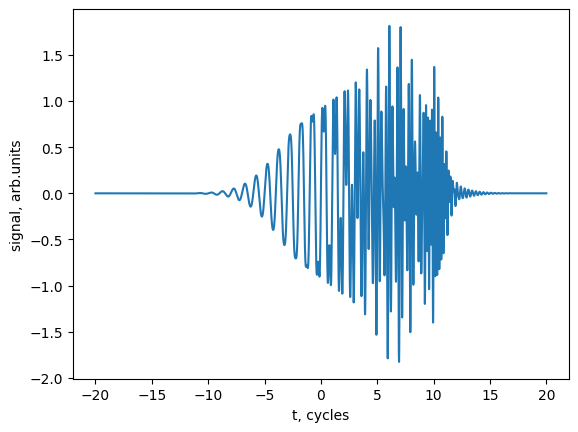

In [13]:
# generate the signal
nofts=1000
t=np.linspace(-20*2*pi, 20*2*pi, 2**14)
# t=np.linspace(-20*2*pi, 20*2*pi, 3**9+6)
y=np.sin(t)*exp(-t**2/2/20**2)
y=y+np.sin(3*t)*exp(-(t-5*2*pi)**2/2/20**2)
y=y+np.sin(5.5*t)*exp(-(t-10*2*pi)**2/2/5**2)
y=y+np.sin(4*t)*exp(-(t-7*2*pi)**2/2/10**2) #Add 4th wave packet (frequency = 4 and time_shift = 7 cycles). Demonstrate the effect on the plot of the FFT spectrum.

plt.plot(t/2/pi,y)

xlabel('t, cycles')
ylabel('signal, arb.units')

Text(0, 0.5, 'Power spectrum, arb. units')

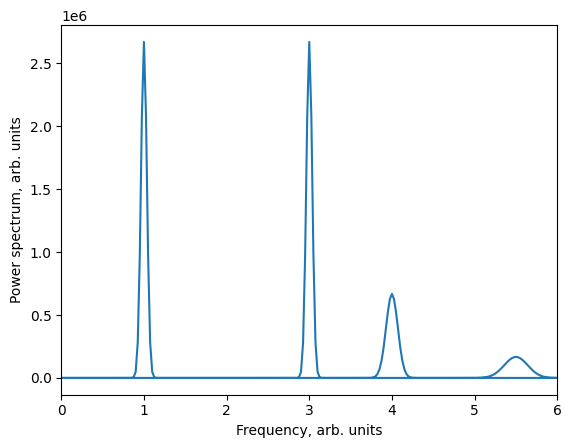

In [14]:
# Fourier spectrum
sp=fft.fft(y)
w=fft.fftfreq(len(y), d=(t[1]-t[0])/2/pi)
plot(w, abs(sp)**2)
xlim(0,6)
xlabel('Frequency, arb. units')
ylabel('Power spectrum, arb. units')

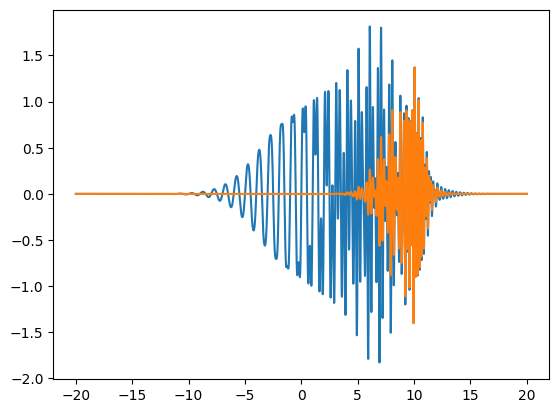

In [15]:
# windowed Fourier transform (Gabor transform, spectrogram)

window_width=2.0*2*pi
window_position=2*10*pi
window_function=exp(-(t-window_position)**2/2/window_width**2)

y_window=y * window_function

plot(t/2/pi, y)
plot(t/2/pi, y_window)

# now do the same for different window positions and plot 2D graph
# x_axis is window position
# y_axis is frequency
# color axis represents the power spectrum

In [29]:
def get_specgram(nwindowsteps=1000):
    spec = zeros((nwindowsteps,len(y)))
    window_width=2.0*2*pi
    i = 0
    for window_position in linspace(-20*2*pi, 20*2*pi, nwindowsteps):
        window_function=exp(-(t-window_position)**2/2/window_width**2)
        y_window=y * window_function
        sp=fft.fft(y_window)
        w=fft.fftfreq(len(y_window), d=(t[1]-t[0])/2/pi)
        spec[i] = abs(sp)**2

        # if spec[i].max() > 700000:
          #  print(i)

        for j, k in enumerate(spec[i]):
            if k > 700000:
                print('(i,j) = (', i, ',', j, ')')

        i += 1
    return spec.transpose()

Implement the spectrogram, show the effect of (1) on the spectrogram.

In [48]:
sp = get_specgram()
# print(sp.shape)
# plt.figure(figsize = (10,10))
# plt.imshow(sp[:200])#, extent=[-20, 20, 0, w.max() - w.min()],  aspect = 'auto')
# plt.ylim(0,6)
# plt.xlabel("Window position")
# plt.ylabel("Frequency, arb. units")
# plt.colorbar()

(i,j) = ( 474 , 40 )
(i,j) = ( 474 , 16344 )
(i,j) = ( 475 , 40 )
(i,j) = ( 475 , 16344 )
(i,j) = ( 476 , 40 )
(i,j) = ( 476 , 16344 )
(i,j) = ( 477 , 40 )
(i,j) = ( 477 , 16344 )
(i,j) = ( 478 , 40 )
(i,j) = ( 478 , 16344 )
(i,j) = ( 479 , 40 )
(i,j) = ( 479 , 16344 )
(i,j) = ( 480 , 40 )
(i,j) = ( 480 , 16344 )
(i,j) = ( 481 , 40 )
(i,j) = ( 481 , 16344 )
(i,j) = ( 482 , 40 )
(i,j) = ( 482 , 16344 )
(i,j) = ( 483 , 40 )
(i,j) = ( 483 , 16344 )
(i,j) = ( 484 , 40 )
(i,j) = ( 484 , 16344 )
(i,j) = ( 485 , 40 )
(i,j) = ( 485 , 16344 )
(i,j) = ( 486 , 40 )
(i,j) = ( 486 , 16344 )
(i,j) = ( 487 , 40 )
(i,j) = ( 487 , 16344 )
(i,j) = ( 488 , 40 )
(i,j) = ( 488 , 16344 )
(i,j) = ( 489 , 40 )
(i,j) = ( 489 , 16344 )
(i,j) = ( 490 , 40 )
(i,j) = ( 490 , 16344 )
(i,j) = ( 491 , 40 )
(i,j) = ( 491 , 16344 )
(i,j) = ( 492 , 40 )
(i,j) = ( 492 , 16344 )
(i,j) = ( 493 , 39 )
(i,j) = ( 493 , 40 )
(i,j) = ( 493 , 41 )
(i,j) = ( 493 , 16343 )
(i,j) = ( 493 , 16344 )
(i,j) = ( 493 , 16345 )
(i,j) = ( 

In [10]:
2**14

16384

In [15]:
%%writefile spectrogram.py
import matplotlib.pyplot as plt
from mpi4py import MPI
import numpy as np
import random
import time
import warnings
import os
warnings.filterwarnings('ignore')

# generate the signal
num = 2**14
nofts=1000
t=np.linspace(-20*2*np.pi, 20*2*np.pi, num)
y=np.sin(t)*np.exp(-t**2/2/20**2)
y=y+np.sin(3*t)*np.exp(-(t-5*2*np.pi)**2/2/20**2)
y=y+np.sin(5.5*t)*np.exp(-(t-10*2*np.pi)**2/2/5**2)
y=y+np.sin(4*t)*np.exp(-(t-7*2*np.pi)**2/2/10**2) #Add 4th wave packet (frequency = 4 and time_shift = 7 cycles). Demonstrate the effect on the plot of the FFT spectrum.


t_start = time.time()

comm = MPI.COMM_WORLD

rank = comm.Get_rank()
size = comm.Get_size()

nwindowsteps = 100000
rank_size = nwindowsteps // size

root = 0

window = np.linspace(-20*2*np.pi, 20*2*np.pi, nwindowsteps)

if rank == size - 1:
    rank_size += nwindowsteps % size
    start, end = rank * rank_size, nwindowsteps
    #print(rank, start, end)


else:
    start, end = rank * rank_size, (rank + 1) * rank_size
    #print(rank, start, end)

steps_number = end - start
#print(steps_number)
spec = np.zeros((steps_number,num))
window_width=2.0*2*np.pi


for i, window_position in enumerate(window[start:end]):
  window_function = np.exp(-(t-window_position)**2/2/window_width**2)
  y_window = y * window_function
  sp = np.fft.fft(y_window)
  w = np.fft.fftfreq(len(y_window), d=(t[1]-t[0])/2/np.pi)
  spec[i] = abs(sp)**2
  #if spec[i].max() > 700000:
    #print(start + i, ', rank = ', rank)
  #for j, k in enumerate(spec[i]):
    #if k > 700000:
      #print('rank = ', rank, '(i,j) = (', start + i, ',', j, ')')



spec_all = None
if rank == 0:
    spec_all = np.empty([size, steps_number, num ], dtype='float')
comm.Gather(spec, spec_all, root=0)

if rank == root:
  t_end = time.time()
  dt = t_end - t_start
  with open('results2.csv', 'a+') as f:
    f.write(f'{dt} ')
  #spec_all_2 = np.zeros(( nwindowsteps, num))
  #spec_all_2[:steps_number] = spec_all[0]
  #spec_all_2[steps_number:] = spec_all[1]
  #np.savetxt("spectrogram.csv", spec_all_2, delimiter=",")





Overwriting spectrogram.py


In [1]:
# !mpirun -n 1 --allow-run-as-root --oversubscribe python3 spectrogram.py
for i in range(5,10):
  !mpirun -n $i --allow-run-as-root --oversubscribe python3 spectrogram.py

--------------------------------------------------------------------------
Primary job  terminated normally, but 1 process returned
a non-zero exit code. Per user-direction, the job has been aborted.
--------------------------------------------------------------------------
--------------------------------------------------------------------------
mpirun noticed that process rank 0 with PID 0 on node f87bf437a7d7 exited on signal 9 (Killed).
--------------------------------------------------------------------------


Text(0, 0.5, 'speedup')

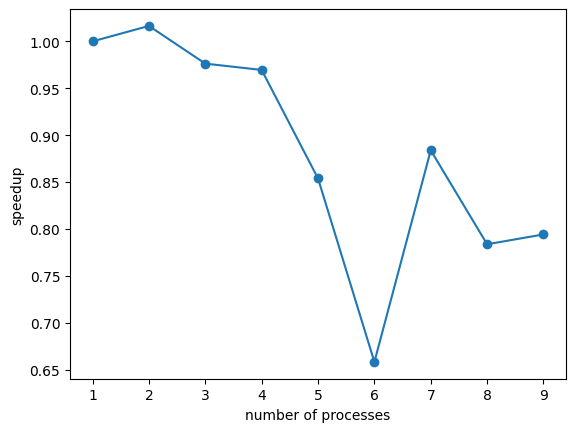

In [4]:
import numpy as np
import matplotlib.pyplot as plt

data = []
with open('results.csv', 'r') as results:
    data = results.readlines()[0].split(' ')
    data = np.array([float(i) for i in data[:-1]] )

plt.plot(np.arange(1, 10, 1),data[0] / data , '-o')
plt.xlabel('number of processes')
plt.ylabel('speedup')

<function matplotlib.pyplot.colorbar(mappable=None, cax=None, ax=None, **kwargs)>

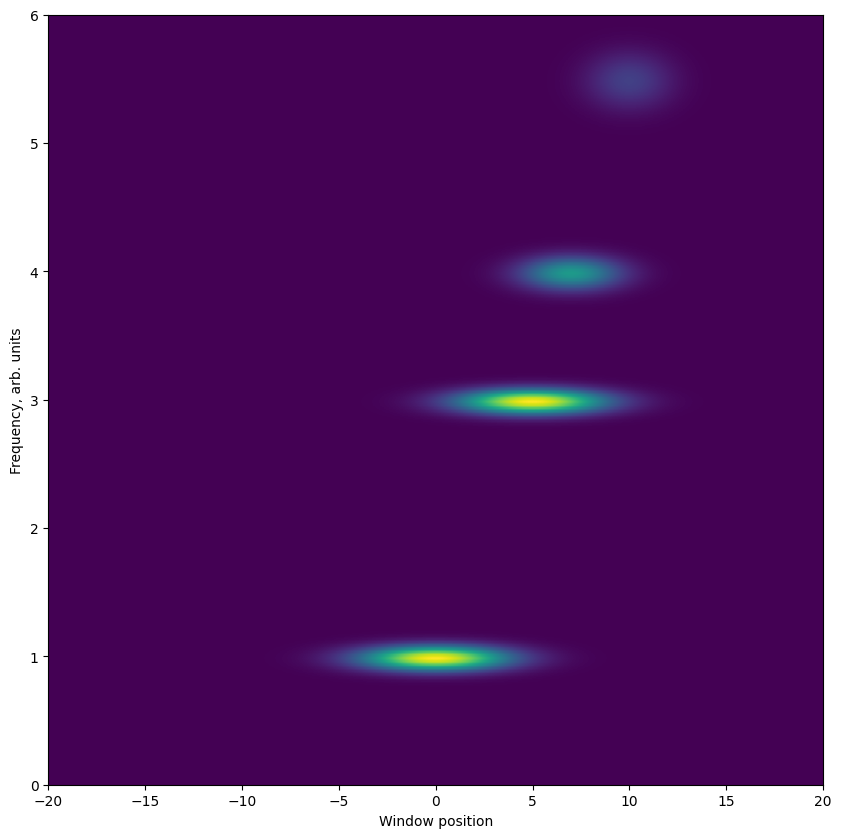

In [109]:
# sp2 = np.genfromtxt('spectrogram.csv', delimiter=',')
plt.figure(figsize = (10,10))
plt.imshow(sp2.transpose(), extent=[-20, 20, 0, w.max() - w.min()],  aspect = 'auto')
plt.ylim(0,6)
plt.xlabel("Window position")
plt.ylabel("Frequency, arb. units")
plt.colorbar

In [107]:
sp2.shape

(1000, 16384)

In [13]:
import numpy as np
import matplotlib.pyplot as plt


In [21]:
!ls

sample_data  spectrogram.csv  spectrogram.py


In [55]:
np.array_equal(sp,sp2)

False

In [91]:
sp.shape

(16384, 1000)

In [85]:
sp2.shape

(16384, 1000)

In [57]:
sp2

array([[2.54533995e-14, 2.54774699e-14, 2.55498460e-14, ...,
        8.10077439e-20, 8.06870230e-20, 8.03679002e-20],
       [8.00503657e-20, 7.97344101e-20, 7.94200239e-20, ...,
        5.40615563e-21, 5.39587020e-21, 5.38561001e-21],
       [5.37537499e-21, 5.36516506e-21, 5.35498015e-21, ...,
        1.20643052e-21, 1.20500250e-21, 1.20357676e-21],
       ...,
       [3.43860617e-13, 3.44268429e-13, 3.44676896e-13, ...,
        1.53425931e-12, 1.53718566e-12, 1.54011922e-12],
       [1.54306002e-12, 1.54600808e-12, 1.54896341e-12, ...,
        2.31518372e-11, 2.32445964e-11, 2.33378255e-11],
       [2.34315273e-11, 2.35257047e-11, 2.36203607e-11, ...,
        1.06206642e-07, 1.06133724e-07, 1.06090009e-07]])

In [60]:
sp[sp > 1]

array([1.00756167, 1.03466648, 1.06225941, ..., 1.06225941, 1.03466648,
       1.00756167])

In [47]:
  for i, n in enumerate(sp):
    for j, k in enumerate(n):
      if k > 700000:
        print('(i,j) = (', i, ',', j, ')')

(i,j) = ( 39 , 493 )
(i,j) = ( 39 , 494 )
(i,j) = ( 39 , 495 )
(i,j) = ( 39 , 496 )
(i,j) = ( 39 , 497 )
(i,j) = ( 39 , 498 )
(i,j) = ( 39 , 499 )
(i,j) = ( 39 , 500 )
(i,j) = ( 39 , 501 )
(i,j) = ( 39 , 502 )
(i,j) = ( 39 , 503 )
(i,j) = ( 39 , 504 )
(i,j) = ( 39 , 505 )
(i,j) = ( 39 , 506 )
(i,j) = ( 40 , 474 )
(i,j) = ( 40 , 475 )
(i,j) = ( 40 , 476 )
(i,j) = ( 40 , 477 )
(i,j) = ( 40 , 478 )
(i,j) = ( 40 , 479 )
(i,j) = ( 40 , 480 )
(i,j) = ( 40 , 481 )
(i,j) = ( 40 , 482 )
(i,j) = ( 40 , 483 )
(i,j) = ( 40 , 484 )
(i,j) = ( 40 , 485 )
(i,j) = ( 40 , 486 )
(i,j) = ( 40 , 487 )
(i,j) = ( 40 , 488 )
(i,j) = ( 40 , 489 )
(i,j) = ( 40 , 490 )
(i,j) = ( 40 , 491 )
(i,j) = ( 40 , 492 )
(i,j) = ( 40 , 493 )
(i,j) = ( 40 , 494 )
(i,j) = ( 40 , 495 )
(i,j) = ( 40 , 496 )
(i,j) = ( 40 , 497 )
(i,j) = ( 40 , 498 )
(i,j) = ( 40 , 499 )
(i,j) = ( 40 , 500 )
(i,j) = ( 40 , 501 )
(i,j) = ( 40 , 502 )
(i,j) = ( 40 , 503 )
(i,j) = ( 40 , 504 )
(i,j) = ( 40 , 505 )
(i,j) = ( 40 , 506 )
(i,j) = ( 40 